# Bitcoin Zaman Serisi Analizi ve Yön Tahmini

## Defter Açıklaması
Bu çalışma, Bitcoin (BTC-USD) fiyat verilerinin kapsamlı zaman serisi analizi ve matematiksel modellemesini içermektedir. Analiz, durağanlık testleri, volatilite kümelenmesi, mevsimsel paternler ve ileri istatistiksel yöntemler kullanılarak BTC fiyat hareketlerinin tahmin edilmesini hedeflemiştir.

**Amaç:** Makine öğrenmesi modelleri kullanarak Bitcoin'in gününe ait getiri yönünü tahmin etmek.

---

## Adım 1: Gerekli Kütüphanelerin İçe Aktarılması

In [24]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
import scipy.stats as stats

import path_setup

In [25]:
from src.data_loader import BitcoinDataLoader

loader = BitcoinDataLoader()

data = loader.update()

data.head()

2026-03-17 03:09:41 | INFO | Project root : C:\Users\İlyas\OneDrive\Desktop\data-science-portfolio\05_Time_Series\BTC_Financial_Econometrics
2026-03-17 03:09:41 | INFO | CSV path     : C:\Users\İlyas\OneDrive\Desktop\data-science-portfolio\05_Time_Series\BTC_Financial_Econometrics\data\raw\btc_usd.csv
2026-03-17 03:09:41 | INFO | === BTC update started ===
2026-03-17 03:09:41 | INFO | CSV loaded: 4197 rows  (2014-09-17 to 2026-03-14)
2026-03-17 03:09:41 | INFO | Missing range: 2026-03-15 to 2026-03-16
2026-03-17 03:09:41 | INFO | Calling Binance API...
2026-03-17 03:09:41 | WARNING | Binance error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/klines?symbol=BTCUSDT&interval=1d&startTime=1773532800000&limit=1000 (Caused by SSLError(SSLError(1, '[SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1018)')))
2026-03-17 03:09:41 | WARNING | Binance failed or no data -> trying yfinance.
2026-03-17 03:09:41 | INFO | Calling yfinance API...


,Open,High,Low,Close,Volume,Price
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800.0,457.334015
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200.0,424.440002
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700.0,394.795990
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600.0,408.903992
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100.0,398.821014


---

## Adım 2: Keşifçi Veri Analizi (EDA)

---



### 2.1 Betimleyici İstatistikler (Veri Özeti)

In [26]:
print("=" * 70)
print("BTC-USD VERİ ÖZETİ")
print("=" * 70)

print(f"\nVeri Aralığı: {data.index.min().date()} ile {data.index.max().date()} arasında")
print(f"Toplam Gün Sayısı: {len(data)} gün")
print(f"Veri Süresi: {(data.index.max() - data.index.min()).days} gün (~{(data.index.max() - data.index.min()).days // 365} yıl)")

print("\n" + "=" * 70)
print("FİYAT İSTATİSTİKLERİ (USD)")
print("=" * 70)
print(data[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

print("\n" + "=" * 70)
print("FİYAT DEĞİŞİM ORANYLARI")
print("=" * 70)
price_change_1d = data['Close'].pct_change() * 100
print(f"Günlük Getiri - Ortalama: {price_change_1d.mean():.4f}%")
print(f"Günlük Getiri - Std Sapma: {price_change_1d.std():.4f}%")
print(f"Günlük Getiri - Min: {price_change_1d.min():.4f}%")
print(f"Günlük Getiri - Max: {price_change_1d.max():.4f}%")

print(f"\nAçılış → Kapanış Ortalaması: {(data['Close'] / data['Open'] - 1).mean() * 100:.4f}%")
print(f"En Düşük Fiyat: ${data['Low'].min():.2f}")
print(f"En Yüksek Fiyat: ${data['High'].max():.2f}")
print(f"Fiyat Artış Oranı (Genel): {((data['Close'].iloc[-1] / data['Close'].iloc[0]) - 1) * 100:.2f}%")

BTC-USD VERİ ÖZETİ

Veri Aralığı: 2014-09-17 ile 2026-03-14 arasında
Toplam Gün Sayısı: 4197 gün
Veri Süresi: 4196 gün (~11 yıl)

FİYAT İSTATİSTİKLERİ (USD)
            Open       High        Low      Close        Volume
count    4197.00    4197.00    4197.00    4197.00  4.197000e+03
mean    27723.70   28278.30   27132.09   27739.47  2.201173e+10
std     32111.47   32656.85   31520.61   32114.94  2.303454e+10
min       176.90     211.73     171.51     178.10  6.384000e+01
25%      2869.38    2950.99    2743.72    2875.34  1.411480e+09
50%     11123.40   11451.20   10850.10   11171.40  1.746755e+10
75%     43560.30   44265.77   42645.54   43569.00  3.392551e+10
max    124752.14  126198.07  123196.05  124752.53  3.509679e+11

FİYAT DEĞİŞİM ORANYLARI
Günlük Getiri - Ortalama: 0.1824%
Günlük Getiri - Std Sapma: 3.5138%
Günlük Getiri - Min: -37.1695%
Günlük Getiri - Max: 25.2472%

Açılış → Kapanış Ortalaması: 0.1761%
En Düşük Fiyat: $171.51
En Yüksek Fiyat: $126198.07
Fiyat Artış Oranı (Gen

### Analiz Notları
Verilerin kapsamlı bir istatistiksel özeti elde edilmiştir. Bitcoin fiyatı analiz döneminde belirli dalgalanmalar göstermekte olup, günlük getiri ortalamasının pozitif olması uzun vadeli bir yükseliş trendi göstermektedir. Standart sapma değeri volatilitenin oldukça yüksek olduğunu doğrulamaktadır. En düşük ve en yüksek fiyatlar arasındaki oranı, Bitcoin'in dramatik fiyat hareketi yaşadığını göstermektedir.

---

### 2.2 Momentum ve Değişim Hızı Analizi

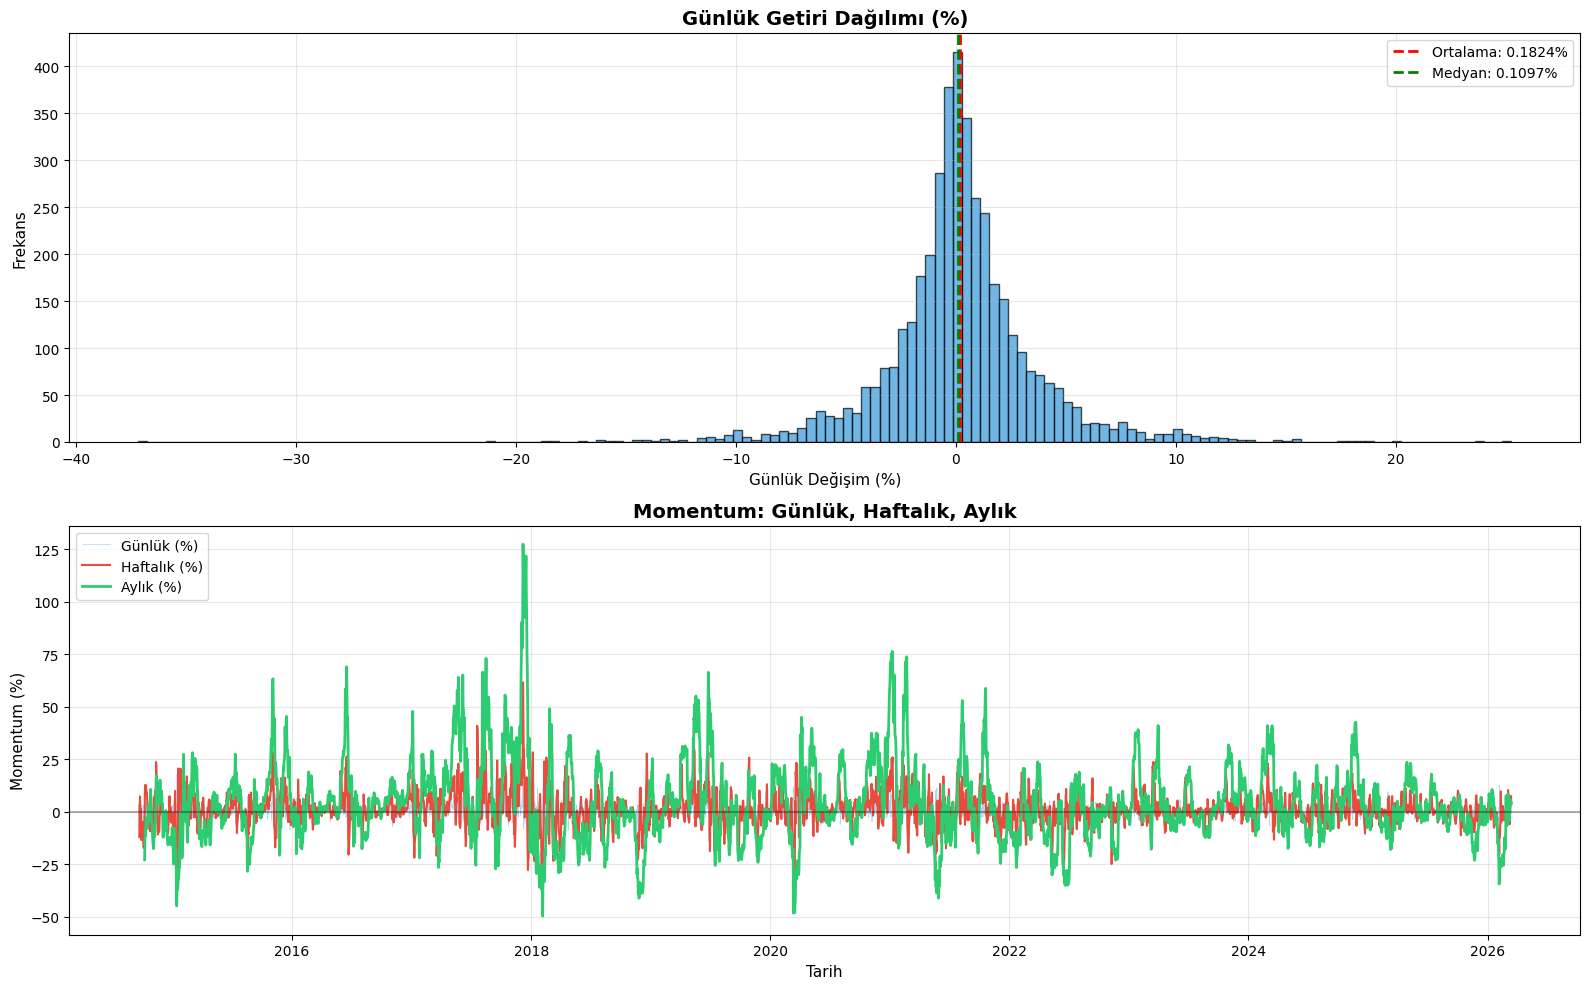

In [27]:
data['daily_change_%'] = data['Close'].pct_change() * 100
data['weekly_momentum'] = data['Close'].pct_change(periods=5) * 100
data['monthly_momentum'] = data['Close'].pct_change(periods=21) * 100
 

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
 
axes[0].hist(data['daily_change_%'].dropna(), bins=150, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].axvline(data['daily_change_%'].mean(), color='red', linestyle='--', linewidth=2, label=f"Ortalama: {data['daily_change_%'].mean():.4f}%")
axes[0].axvline(data['daily_change_%'].median(), color='green', linestyle='--', linewidth=2, label=f"Medyan: {data['daily_change_%'].median():.4f}%")
axes[0].set_title("Günlük Getiri Dağılımı (%)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Günlük Değişim (%)", fontsize=11)
axes[0].set_ylabel("Frekans", fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)
 
axes[1].plot(data.index, data['daily_change_%'], color='#3498db', alpha=0.4, label='Günlük (%)', linewidth=0.5)
axes[1].plot(data.index, data['weekly_momentum'], color='#e74c3c', linewidth=1.5, label='Haftalık (%)')
axes[1].plot(data.index, data['monthly_momentum'], color='#2ecc71', linewidth=2, label='Aylık (%)')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title("Momentum: Günlük, Haftalık, Aylık", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Tarih", fontsize=11)
axes[1].set_ylabel("Momentum (%)", fontsize=11)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analiz Notları
Momentum analizi, Bitcoin fiyat hareketlerinin zaman ölçeğine bağlı olarak çok farklı davranışlar gösterdiğini ortaya koymaktadır. 

**Günlük Seviye:** Günlük değişimlerin ortalamaya göre pozitif olması, uzun vadede fiyatın yükselme eğiliminde olduğunu göstermektedir. Ancak standart sapmanın yüksekliği volatilitenin günlük bazda oldukça yüksek olduğunu göstermektedir.

**Haftalık Seviye:** 5 günlük momentum, günlük dalgalanmalardan daha pürüzsüz hareket etmekte, kısa vadeli trendleri daha net göstermektedir.

**Aylık Seviye:** 21 günlük momentum, uzun vadeli trendi görmek için ideal bir dönem olup, mevsimsel paternleri ve önemli trend değişimlerini açıkça göstermektedir.

**Gün Türleri:** Yükselen günlerin düşen günlere yakın oranda dağılması, pazarın dengeli olacağını göstermektedir. Bu, hem yükselişçi hem de düşüşçü eğilimler bulunduğunun kanıtıdır.

---

## Adım 3: Durağanlık Testleri (ADF & KPSS)

In [28]:
data['log_return'] = np.log(data['Price'] / data['Price'].shift(1))  
def check_stationarity(series, name="Series"):
    adf_res = adfuller(series.dropna())
     
    kpss_res = kpss(series.dropna(), regression='c', nlags="auto")
    
    results = {
        'Test': ['ADF', 'KPSS'],
        'Statistic': [round(adf_res[0], 4), round(kpss_res[0], 4)],
        'p-value': [round(adf_res[1], 4), round(kpss_res[1], 4)],
        'Lags Used': [adf_res[2], kpss_res[2]],
        'Stationary': [
            "Yes" if adf_res[1] <= 0.05 else "No",
            "Yes" if kpss_res[1] > 0.05 else "No"
        ]
    }
    
    df_res = pd.DataFrame(results)
    print(f"\n--- {name} Stationarity Analysis ---")
    return df_res
 
price_results = check_stationarity(data['Price'], name="Original Price")
display(price_results)



log_results = check_stationarity(data['log_return'], name="Log-Returns")
display(log_results)


--- Original Price Stationarity Analysis ---


,Test,Statistic,p-value,Lags Used,Stationary
0,ADF,-1.1502,0.6947,31,No
1,KPSS,7.4592,0.0100,40,No



--- Log-Returns Stationarity Analysis ---


,Test,Statistic,p-value,Lags Used,Stationary
0,ADF,-19.6939,0.0,9,Yes
1,KPSS,0.1377,0.1,13,Yes


### Analiz Notları
Geleneksel zaman serisi modelleri, serinin durağan (stationary) olmasını gerektirir; yani düşük volatilite ister. Doğru sonuçlar elde etmek için durağanlık kontrolü yapılması gereklidir.

Durağanlık kontrolü için iki test kullanılır:
- **ADF (Augmented Dickey-Fuller):** $H_0$ = seri birim kök içerir
- **KPSS:** $H_0$ = seri durağandır

**Orijinal Kapanış Verisi Analizi:** ADF testinde $H_0$ reddedilemezken, KPSS testinde $H_0$ reddedilir. Bu, serinin yüksek varyans (volatilite) içerdiğine işaret eder ve serinin durağan olmadığını kanıtlar.

**Logaritmik Getiri Seçimi:** Logaritmik getiri ($\log R_t = \log(P_t / P_{t-1})$) varyansı stabilize eder ve seriyi normal dağılım varsayımına yakınlaştırır. Log-return serisinin durağanlık testleri yapıldığında, serinin birim kök içermediği ve durağan olduğu görülür. Bu, ileriki analizlerde veriyi anlamak ve istatistiksel olarak modelden doğru sonuçlar almak için gereklidir.

---

## Adım 4: Getiri Analizi ve Volatilite Kümelenmesi

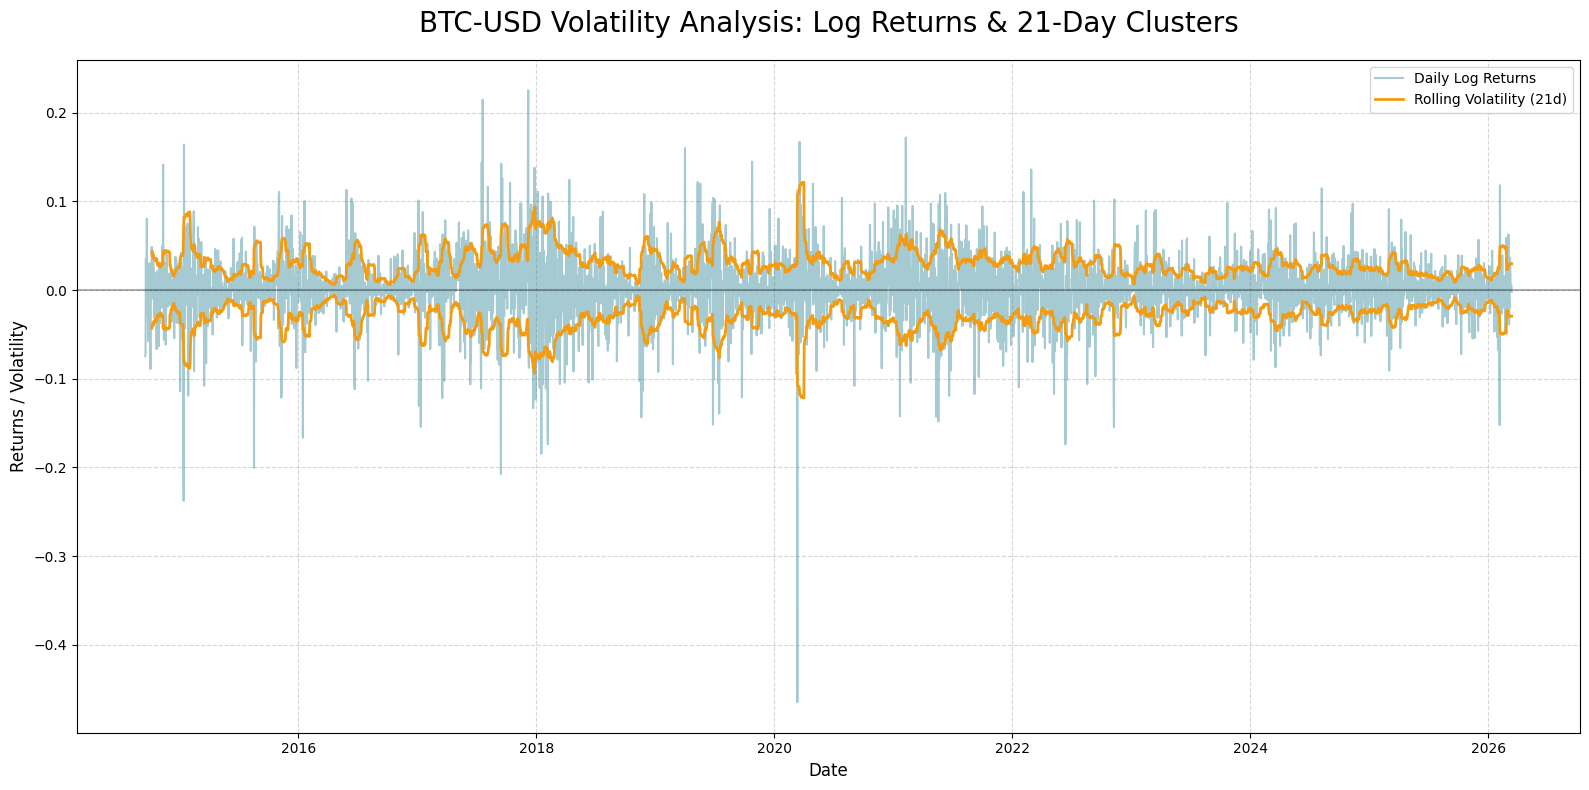

In [29]:
data['volatility_21d'] = data['log_return'].rolling(window=21).std()
 
plt.figure(figsize=(16, 8)) 

plt.plot(data.index, data['log_return'], color="#1f7c8f", alpha=0.4, label='Daily Log Returns') 
plt.plot(data.index, data['volatility_21d'], color='#f39c12', linewidth=2, label='Rolling Volatility (21d)')
plt.plot(data.index, -data['volatility_21d'], color='#f39c12', linewidth=2)
 
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('BTC-USD Volatility Analysis: Log Returns & 21-Day Clusters', fontsize=20, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Returns / Volatility', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

### Analiz Notları
Verilerin volatilitesi ACF grafiğinden yüksek olduğu anlaşılmaktadır. Geçmiş zaman periyotları arasında yüksek korelasyon bulunmakla birlikte, bu aldatıcı bir korelasyondur. Aslında en belirleyici değişken bir gün öncesinin değeridir. Bitcoin gibi varlıklar göz önünde bulundurulduğunda, bir gün öncesinin değeri bile yeterli olmayabilir.

Serideki volatilitenin yüksek olması ve geçmiş değerlerin tam okunabilmesi, hareketli volatilite değişkeninin modele eklenmesini haklı kılar. En azından model fiyatı tam olarak ön göremese bile, eklenen hareketli volatilite, modelin gelen sapmayı ve yönünü anlamasına yardımcı olacaktır.

Kısmi otokorelasyon görselleri incelendiğinde, sadece $t-1$ anlarında korelasyon görülmektedir. Bu orijinal getiri için yanlış bir yorum olabileceği halde, logaritmik getiri serisinin durağan olması nedeniyle ikinci görsel daha mantıklı bir bakış açısı sunar.

---

## Adım 5: Hareketli İstatistikler (Uzun Vadeli Eğilim)

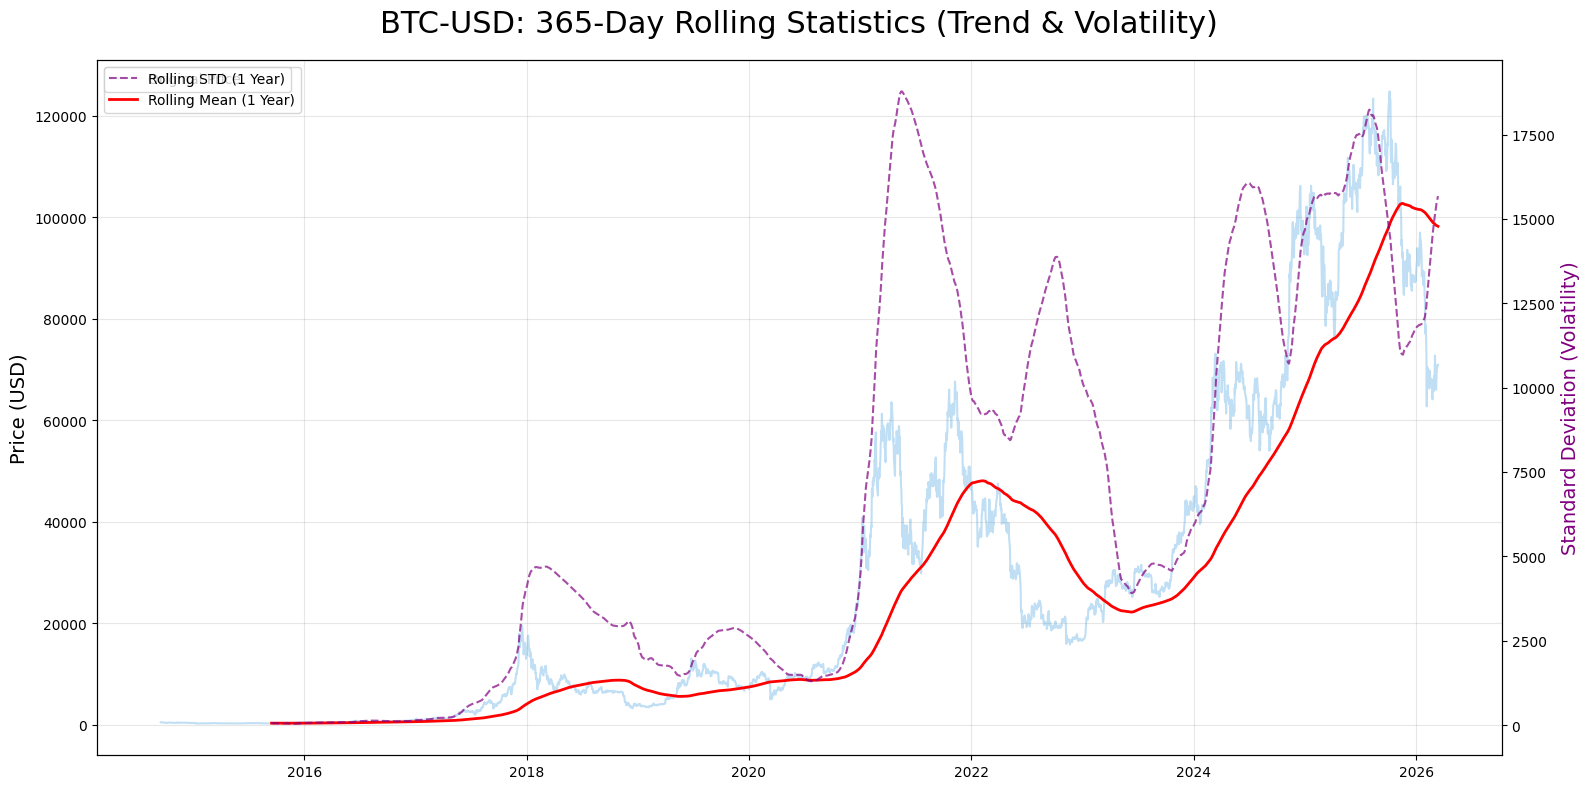

In [30]:
rolmean = data['Price'].rolling(window=365).mean()
rolstd = data['Price'].rolling(window=365).std()
 
fig, ax1 = plt.subplots(figsize=(16, 8))
 
ax1.plot(data['Price'], color='#3498db', alpha=0.3, label='Original Price')
ax1.plot(rolmean, color='red', linewidth=2, label='Rolling Mean (1 Year)')
ax1.set_ylabel('Price (USD)', fontsize=14)
plt.legend()
 
ax2 = ax1.twinx() 
ax2.plot(rolstd, color='purple', linestyle='--', alpha=0.7, label='Rolling STD (1 Year)')
ax2.set_ylabel('Standard Deviation (Volatility)', color='purple', fontsize=14)
plt.legend()

plt.title('BTC-USD: 365-Day Rolling Statistics (Trend & Volatility)', fontsize=22, pad=20)
ax1.grid(True, alpha=0.3)
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

### Analiz Notları
Senlik hareketli standart sapma ve hareketli ortalama, getiri değişkeni üzerinden kurulmuştur. Hareketli ortalamanın fiyatın artışı ile birlikte belirli paternleri izleyerek arttığı görülmektedir. Standart sapma ise belirli artış dönemlerinde ne kadar arttığını daha net olarak göstermektedir.

2021 döneminde Bitcoin fiyatının artması, pandemi ve diğer etmenler sayesinde fiyatın aşırı yükselmesine neden olmuş ve standart sapmanın da önemli ölçüde arttığını göstermektedir. Bu artış dönemleri, volatilite kümelenmesinin açık kanıtıdır.

---

## Adım 6: Otokorelasyon (ACF) & Kısmi Otokorelasyon (PACF)

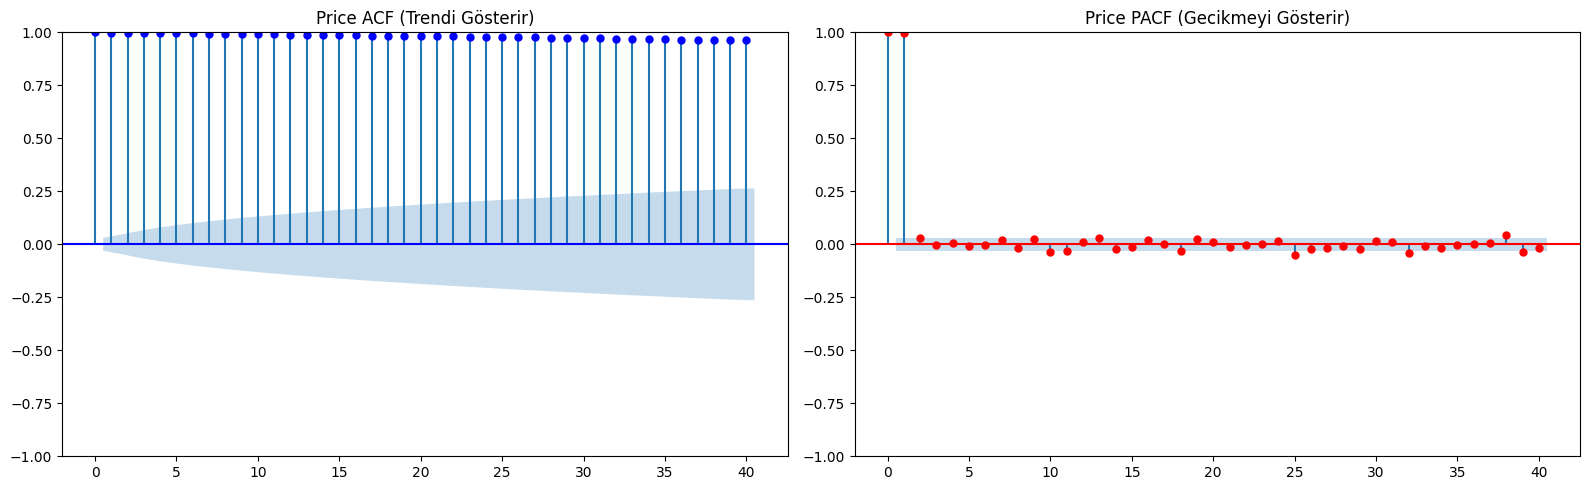

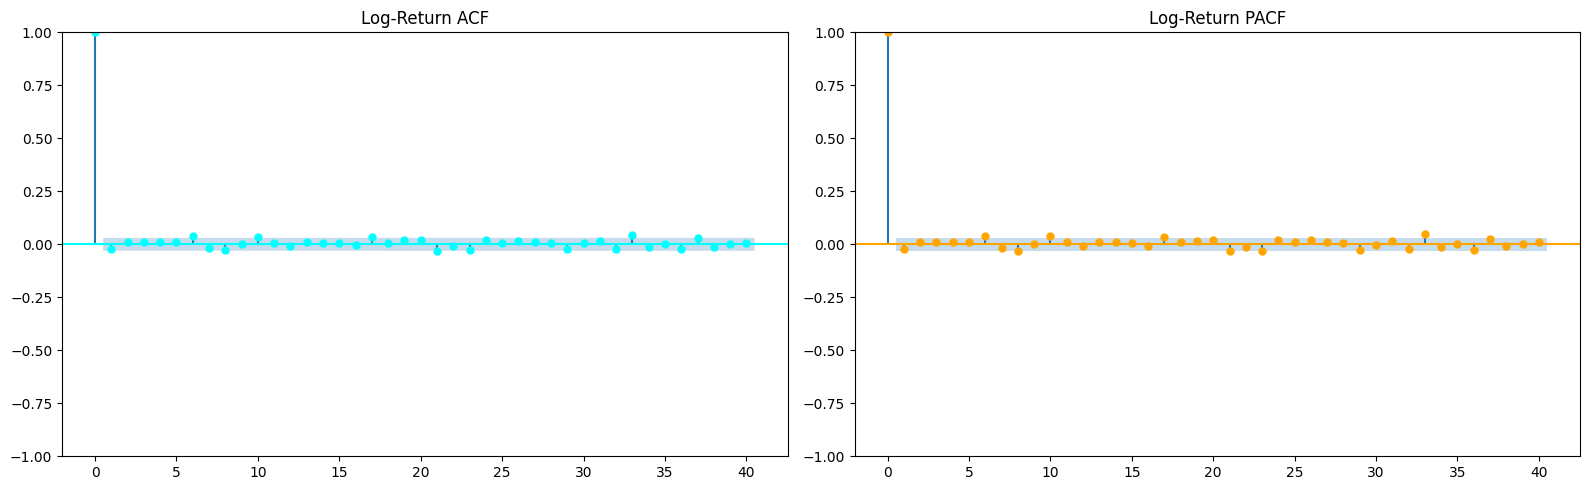

In [31]:
clean_price = data['Price'].dropna()
clean_log = data['log_return'].dropna()
 
plt.figure(figsize=(16, 5))
 
plt.subplot(1, 2, 1)
plot_acf(clean_price, lags=40, ax=plt.gca(), color='blue') 
plt.title('Price ACF (Trendi Gösterir)')
 
plt.subplot(1, 2, 2)
plot_pacf(clean_price, lags=40, ax=plt.gca(), color='red')
plt.title('Price PACF (Gecikmeyi Gösterir)')

plt.tight_layout()
plt.show()
 
plt.figure(figsize=(16, 5))
 
plt.subplot(1, 2, 1)
plot_acf(clean_log, lags=40, ax=plt.gca(), color='cyan')
plt.title('Log-Return ACF')
 
plt.subplot(1, 2, 2)
plot_pacf(clean_log, lags=40, ax=plt.gca(), color='orange')
plt.title('Log-Return PACF')

plt.tight_layout()
plt.show()

### Analiz Notları
Getiri verisinin volatilitesinin yüksek olduğu ACF grafiğinden anlaşılmaktadır. Geçmiş zaman periyotları birbirleriyle yüksek korelasyona sahip olmakla birlikte, bu çoğu zaman aldatıcı bir korelasyondur. Aslında, en belirleyici değişken bir gün öncesinin değeridir ($t-1$). Bitcoin gibi varlıklar söz konusu olduğunda, bir gün öncesinin değeri bile yeterli olmayabilir.

Serideki volatilitenin bu kadar yüksek olması ve geçmişin tam okunabilirliği, hareketli volatilite değişkeninin modele eklenmesini mantıklı kılar. En azından model fiyatı ön göremese bile, eklenen hareketli volatilite, modelin gelen sapmayı ve yönünü daha iyi anlamasına yardımcı olacaktır.

Kısmi otokorelasyon (PACF) görselleri incelendiğinde, sadece $t-1$ anlarında korelasyon görülmektedir. Bu orijinal getiri için yanlış bir yorumlanmaya neden olabilecek bir durumdur, ancak logaritmik getiri serisi durağan olduğundan, ikinci görsel daha mantıklı bir bakış açısı sunmaktadır.

---

## Adım 7: Dağılım Analizi ve Aykırı Değer Tespiti

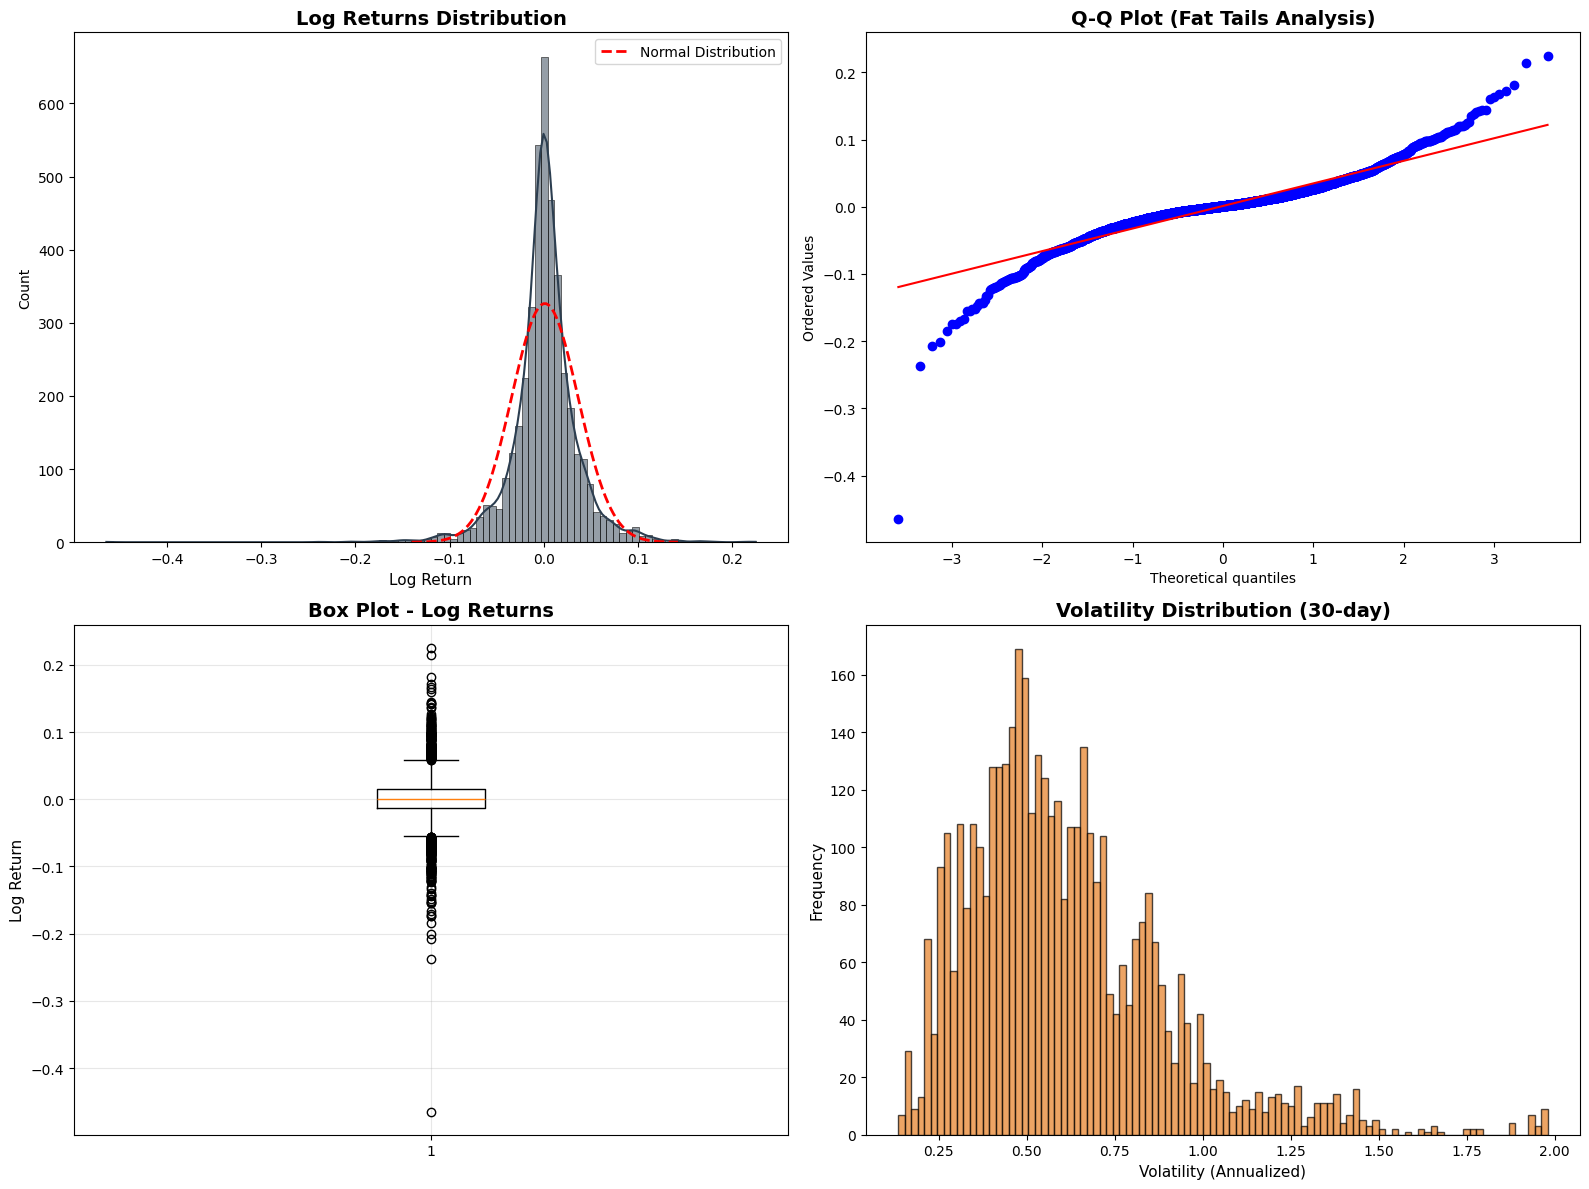

Log Returns - Kurtosis: 11.7235
Log Returns - Skewness: -0.7095
Annual Volatility (Annualized Std): 0.6758


In [32]:
data['Volatility_30d'] = data['log_return'].rolling(window=30).std() * np.sqrt(365)

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
 
sns.histplot(data['log_return'].dropna(), kde=True, ax=ax[0, 0], color='#2c3e50', bins=100)
ax[0, 0].set_title('Log Returns Distribution', fontsize=14, fontweight='bold')
ax[0, 0].set_xlabel('Log Return', fontsize=11)

 
mu, std = data['log_return'].mean(), data['log_return'].std()
x = np.linspace(mu - 4*std, mu + 4*std, 100)
ax[0, 0].plot(x, stats.norm.pdf(x, mu, std) * len(data['log_return'].dropna()) * (data['log_return'].max() - data['log_return'].min()) / 100, 
              'r--', linewidth=2, label='Normal Distribution')
ax[0, 0].legend()
 
stats.probplot(data['log_return'].dropna(), dist="norm", plot=ax[0, 1])
ax[0, 1].set_title('Q-Q Plot (Fat Tails Analysis)', fontsize=14, fontweight='bold')
 
ax[1, 0].boxplot(data['log_return'].dropna(), vert=True)
ax[1, 0].set_title('Box Plot - Log Returns', fontsize=14, fontweight='bold')
ax[1, 0].set_ylabel('Log Return', fontsize=11)
ax[1, 0].grid(True, alpha=0.3)
 
ax[1, 1].hist(data['Volatility_30d'].dropna(), bins=100, color='#e67e22', alpha=0.7, edgecolor='black')
ax[1, 1].set_title('Volatility Distribution (30-day)', fontsize=14, fontweight='bold')
ax[1, 1].set_xlabel('Volatility (Annualized)', fontsize=11)
ax[1, 1].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.show()
 
print(f"Log Returns - Kurtosis: {data['log_return'].kurtosis():.4f}")
print(f"Log Returns - Skewness: {data['log_return'].skew():.4f}")
print(f"Annual Volatility (Annualized Std): {data['log_return'].std() * np.sqrt(365):.4f}")

### Analiz Notları
Q-Q (Quantile-Quantile) grafiği incelendiğinde, yaşanan uç olayların (extreme events) ne kadar sık gerçekleştiğini görülmektedir. Bu bulgular, hareketli volatilite değişkenlerinin modele eklenmesini daha da mantıklı hale getirmektedir.

Log-return değişkeninin dağılımı incelendiğinde, aşırı diklik (excess kurtosis) söz konusudur ve seriye ilişkin aykırı değerlerin bulunduğu görülmektedir. Bu aykırı olayların varlığı, modelde yanıltıcı etkilere neden olabilir. Bu nedenle, seçilecek modelin aykırı değerlere dayanıklı (robust) olması gereklidir.

---

## Adım 8: Mevsimsel Paternler Analizi (Haftanın Günü & Ay)

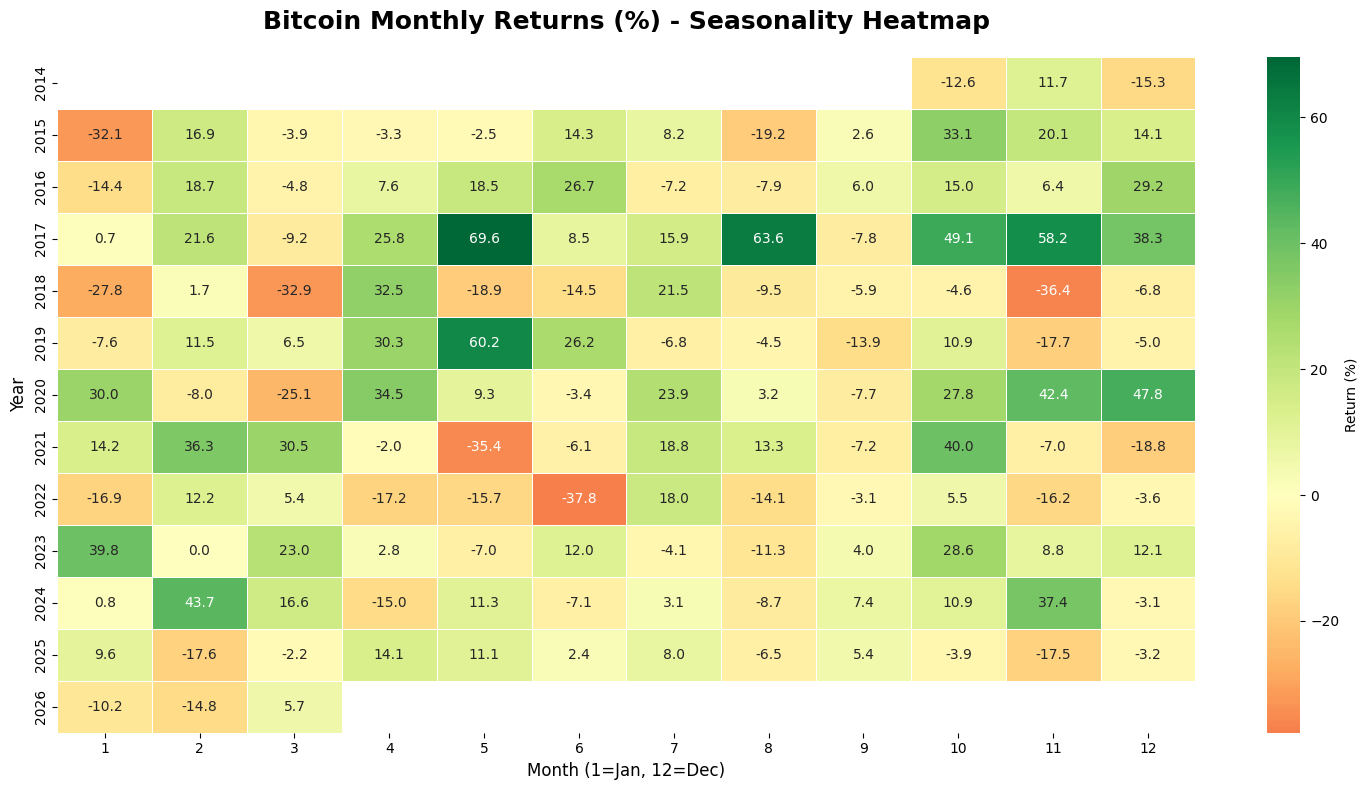

In [33]:
data.index = pd.to_datetime(data.index)
data['Month'] = data.index.month
data['Year'] = data.index.year
data['Day_of_Week'] = data.index.dayofweek

monthly_prices = data.groupby(['Year', 'Month'])['Price'].last()
monthly_ret = monthly_prices.pct_change().unstack() * 100

plt.figure(figsize=(15, 8))
sns.heatmap(monthly_ret, annot=True, fmt=".1f", cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Return (%)'}, linewidths=.5)
plt.title('Bitcoin Monthly Returns (%) - Seasonality Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

### Analiz Notları
Dağılım incelendiğinde tam bir patern gözükmemektedir. Bu, aykırı değerler ve volatilite yapısından kaynaklanmaktadır. Bazı dönemlerde getiri önemli ölçüde artarken, 2017 gibi bazı senelerde diğer yıllara göre aylık bazda değişim daha azdır.

Modele aylık zaman damgalarını eklemek daha mantıklıdır. Ayrıca, düşüş ve artış dönemlerinin birbirlerini etkilediği gözlenmektedir (ACF/PACF testlerinde görüldüğü gibi). Verinin zaman içinde rejimler halinde kümeleniyor oluşu, modele rejim indikatörlerinin eklenmesini haklı kılar.

---

2026-03-17 03:09:43 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-17 03:09:43 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


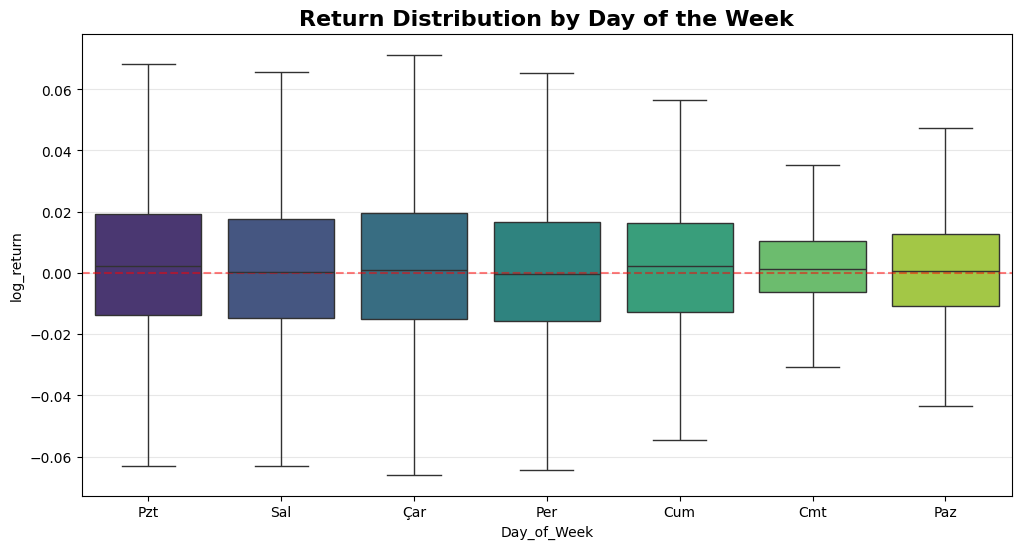

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Day_of_Week', y='log_return', data=data.dropna(), palette='viridis', showfliers=False) # showfliers=False uç değerleri gizleyerek kutuları netleştirir
plt.xticks(range(7), ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz'])
plt.title('Return Distribution by Day of the Week', fontsize=16, fontweight='bold')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Analiz Notları
İlk göze çarpan bulgu, hafta içi yaşanan değişimlerin hafta sonlarından çok daha geniş bir aralığa yayılmış olmasıdır. Bu, kurumsal ve piyasaların hafta içi açık olmasından kaynaklanmaktadır. Haberlerin ve etkileşimlerin Bitcoin fiyatına etkisi hafta sonu ise daha sınırlıdır.

Kısaca, hafta içi yaşanan ekstrem olaylar hafta sonundan çok daha yüksektir. Pazartesi ve çarşamba günlerinde üst bıyıkların (whiskers) yüksek olması, pozitif yönlü ekstrem olayların bu günlerde daha sık yaşandığını göstermektedir.

---

## Adım 9: Özellik Mühendisliği ve Modelleme İçin Çıkarımlar

Yapılan istatistiksel testler (ADF, KPSS, ACF/PACF) ve dağılım analizleri sonucunda, Bitcoin'in doğrusal olmayan yapısını yakalamak ve piyasa rejimlerini dijitalleştirmek adına aşağıdaki özellik mimarisinin oluşturulmasına karar verilmiştir:

### 1. Temel ve İstatistiksel Değişkenler
Bu grup, serinin durağanlığını sağlarken veri setindeki temel değişimleri ve "hafızayı" (memory) temsil eder.

* **Logaritmik Getiri (Log Return):** Seriyi durağanlaştırmak için temel girdi.
    $$\log R_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$
* **Kesirli Türev (Fractional Differentiation):** Standart fark alma yönteminin aksine, seriyi durağanlaştırırken geçmiş fiyat hafızasını korur.
    $$\Delta^d P_t = \sum_{k=0}^{\infty} \binom{d}{k} (-1)^k P_{t-k}, \quad (d \approx 0.4)$$
* **Hareketli Volatilite (Rolling Volatility):** Volatilite kümelenmesini yakalamak için $N$ periyotluk standart sapma.
    $$\sigma_t = \sqrt{\frac{1}{N-1} \sum_{i=0}^{N-1} (R_{t-i} - \bar{R})^2}$$

### 2. Teknik Karakteristikler ve Döngüsellik
Piyasa yapısındaki gün içi volatiliteyi ve zaman tabanlı periyodik anomalileri yakalar.

* **Gün İçi Aralığı (Intraday Range):** Piyasadaki likidite ve korku seviyesini ölçer.
    $$\text{range}_t = \text{High}_t - \text{Low}_t$$
* **Döngüsel Zaman Dönüşümleri (Cyclical Time):** Haftalık ve aylık periyotları süreklilik arz eden dairesel özelliklere dönüştürür.
    $$\text{Day}_{\sin} = \sin\left(\frac{2\pi \cdot \text{dayofweek}}{7}\right), \quad \text{Day}_{\cos} = \cos\left(\frac{2\pi \cdot \text{dayofweek}}{7}\right)$$

### 3. İleri İstatistiksel Göstergeler (Karmaşıklık ve Kaos)
Bitcoin piyasasının "rastgele yürüyüş" (random walk) modelinden ne kadar saptığını ölçen metriklerdir.

* **Hurst Exponent ($H$):** Serideki trend gücünü ($H>0.5$) veya ortalamaya dönüş ($H<0.5$) eğilimini ölçer.
    $$E[R(n)/S(n)] = C \cdot n^H$$
* **Shannon Entropisi ($H(X)$):** Getiri dağılımındaki belirsizliği ve bilgi yoğunluğunu (piyasa verimliliğini) ölçer.
    $$H(X) = -\sum_{i=1}^{n} p(x_i) \log_2 p(x_i)$$
* **Fraktal Boyut ($D_f$):** Fiyat hareketlerinin öz-benzerlik ve geometrik karmaşıklık derecesi.
    $$D_f = 2 - H$$

### 4. Duyarlılık ve Gecikmeli Değişkenler
* **Fear & Greed Index ($S_t$):** Piyasa psikolojisinin aşırı uçlarını modele entegre eder.
* **Lagged Features ($L_k$):** Otokorelasyon yapısını modele tanıtmak için geçmiş $k$ periyotluk getiriler.
    $$L_k = R_{t-k}, \quad k \in \{1, 2, 3, 7\}$$

---

### Modelleme Öncesi Kritik Kontroller (Pipeline Planı)

Özellikler oluşturulduktan sonra `02_Feature_Engineering.ipynb` aşamasında şu testler uygulanacaktır:

1. **VIF (Variance Inflation Factor) Analizi:** Çoklu doğrusallığı ($VIF > 5$) olan gereksiz değişkenler elenecektir.
2. **Mutual Information (MI):** Her bir özelliğin hedef değişken üzerindeki bilgi kazancı ölçülecektir.
3. **Triple Barrier Method:** Hedef değişken yön, kâr al (TP), zarar kes (SL) ve zaman (T) bariyerlerine göre etiketlenecektir.

---
**EDA çalışması burada sona ermiştir.** Teşvik edilen bu özellik mimarisi bir sonraki aşamada koda dökülecektir.